imports:

In [1]:
import numpy as np
from pathlib import Path
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA RTX A6000


cultivar directory:

In [2]:
DATASET_DIR = Path("Dataset")

CULTIVARS = {
    "AAC_Chrome":     {"label": "AAC Chrome",    "cys": 0.317211},
    "AAC_Lacombe":    {"label": "AAC Lacombe",   "cys": 0.338561},
    "AAC_Liscard":    {"label": "AAC Liscard",   "cys": 0.325405},
    "CDC_Amarillo":   {"label": "CDC Amarillo",  "cys": 0.358930},
    "CDC_Athabasca":  {"label": "CDC Athabasca", "cys": 0.341203},
    "CDC_Canary":     {"label": "CDC Canary",    "cys": 0.314476},
    "CDC_Dakota":     {"label": "CDC Dakota",    "cys": 0.332835},
    "CDC_Golden":     {"label": "CDC Golden",    "cys": 0.359066},
    "CDC_Greenwater": {"label": "CDC Greenwater","cys": 0.346381},
    "CDC_Inca":       {"label": "CDC Inca",      "cys": 0.365342},
    "CDC_Jasper":     {"label": "CDC Jasper",    "cys": 0.337341},
    "CDC_Lewochko":   {"label": "CDC Lewochko",  "cys": 0.341267},
    "CDC_Meadow":     {"label": "CDC Meadow",    "cys": 0.312012},
    "CDC_Patrick":    {"label": "CDC Patrick",   "cys": 0.338404},
    "CDC_Saffron":    {"label": "CDC Saffron",   "cys": 0.346789},
    "CDC_Spectrum":   {"label": "CDC Spectrum",  "cys": 0.373175},
    "CDC_Spruce":     {"label": "CDC Spruce",    "cys": 0.345676},
    "CDC_Striker":    {"label": "CDC Striker",   "cys": 0.344968},
    "CDC_Tetris":     {"label": "CDC Tetris",    "cys": 0.342040},
    "Redbat88":       {"label": "Redbat 88",     "cys": 0.316257},
}

read_spectrum:

In [3]:
def read_spectrum(filepath):
    raman_shifts = []
    intensities = []

    with open(filepath, 'r', encoding='latin-1') as f:
        lines = f.readlines()

    data_started = False
    for line in lines:
        line = line.strip()
        if line.startswith("Pixel;"):
            data_started = True
            continue
        if not data_started:
            continue
        parts = line.split(';')
        if len(parts) < 8:
            continue
        wl_str = parts[1].strip()
        if not wl_str or wl_str == '   ':
            continue
        try:
            raman_shift = float(parts[3])
            dark_sub    = float(parts[7])
            raman_shifts.append(raman_shift)
            intensities.append(dark_sub)
        except ValueError:
            continue

    return raman_shifts, intensities

Load all spectra:

In [4]:
all_data = {}

for folder_name, meta in CULTIVARS.items():
    folder_path = DATASET_DIR / folder_name
    if not folder_path.exists():
        print(f"Not found: {folder_name}")
        continue
    files = list(folder_path.rglob("*.txt"))
    spectra = []
    for f in files:
        rs, intens = read_spectrum(f)
        if len(rs) > 100:
            spectra.append((rs, intens))
    all_data[folder_name] = spectra
    print(f"{meta['label']}: {len(spectra)} spectra loaded")

AAC Chrome: 324 spectra loaded
AAC Lacombe: 324 spectra loaded
AAC Liscard: 324 spectra loaded
CDC Amarillo: 324 spectra loaded
CDC Athabasca: 324 spectra loaded
CDC Canary: 324 spectra loaded
CDC Dakota: 324 spectra loaded
CDC Golden: 324 spectra loaded
CDC Greenwater: 324 spectra loaded
CDC Inca: 324 spectra loaded
CDC Jasper: 324 spectra loaded
CDC Lewochko: 324 spectra loaded
CDC Meadow: 324 spectra loaded
CDC Patrick: 324 spectra loaded
CDC Saffron: 324 spectra loaded
CDC Spectrum: 324 spectra loaded
CDC Spruce: 324 spectra loaded
CDC Striker: 324 spectra loaded
CDC Tetris: 324 spectra loaded
Redbat 88: 324 spectra loaded


Preprocessing functions and combos:

In [5]:
def savitzky_golay_smooth(X, window=11, poly=3):
    return savgol_filter(X, window_length=window, polyorder=poly, axis=1)

def snv(X):
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True)
    return (X - mean) / std

def msc(X):
    mean_spectrum = X.mean(axis=0)
    X_msc = np.zeros_like(X)
    for i in range(X.shape[0]):
        coef = np.polyfit(mean_spectrum, X[i], 1)
        X_msc[i] = (X[i] - coef[1]) / coef[0]
    return X_msc

def first_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=1, axis=1)

def second_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=2, axis=1)

preprocessing_combos = {
    "SG + SNV":           lambda X: snv(savitzky_golay_smooth(X)),
    "SG + MSC":           lambda X: msc(savitzky_golay_smooth(X)),
    "SG + 1st Deriv":     lambda X: first_derivative(savitzky_golay_smooth(X)),
    "SG + 2nd Deriv":     lambda X: second_derivative(savitzky_golay_smooth(X)),
    "SG + SNV + 1st Der": lambda X: first_derivative(snv(savitzky_golay_smooth(X))),
    "SG + SNV + 2nd Der": lambda X: second_derivative(snv(savitzky_golay_smooth(X))),
    "SG + MSC + 1st Der": lambda X: first_derivative(msc(savitzky_golay_smooth(X))),
    "SG + MSC + 2nd Der": lambda X: second_derivative(msc(savitzky_golay_smooth(X))),
}

print(f"Preprocessing combinations: {len(preprocessing_combos)}")

Preprocessing combinations: 8


Build X and y:

In [6]:
X = []
y = []

for folder_name, meta in CULTIVARS.items():
    spectra = all_data.get(folder_name, [])
    for rs, intens in spectra:
        X.append(intens)
        y.append(meta['cys'])

X = np.array(X)
y = np.array(y)

cultivar_names = list(CULTIVARS.keys())

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (6480, 1530)
y shape: (6480,)


Prep the input for the autoencoder:

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Preprocess: SG smooth then SNV
X_ae = snv(savitzky_golay_smooth(X))          # shape (6480, 1530)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

X_tensor = torch.tensor(X_ae, dtype=torch.float32)

# Unsupervised: input and target are the same spectrum
ae_dataset = TensorDataset(X_tensor, X_tensor)
ae_loader  = DataLoader(ae_dataset, batch_size=64, shuffle=True)

print("Autoencoder input shape:", X_tensor.shape)

Device: cuda
Autoencoder input shape: torch.Size([6480, 1530])


The autoencoder:

In [8]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=1530, bottleneck=32):
        super().__init__()

        # Encoder: squeeze 1530 down to 32
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, bottleneck)   # bottleneck, no activation
        )

        # Decoder: rebuild 1530 from 32
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)      # compressed features
        out = self.decoder(z)    # reconstruction
        return out

    def encode(self, x):
        return self.encoder(x)   # used later for feature extraction

model = Autoencoder(input_dim=X_tensor.shape[1], bottleneck=32).to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", n_params)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=1530, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=1530, bias=True)
  )
)
Total parameters: 1708826


Train the autoencoder:

In [9]:
import copy

model = Autoencoder(input_dim=X_tensor.shape[1], bottleneck=32).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 200
best_loss = float('inf')
best_state = None
history = []

for epoch in range(epochs):
    model.train()
    running = 0.0
    for xb, _ in ae_loader:
        xb = xb.to(device)
        optimizer.zero_grad()
        recon = model(xb)
        loss = criterion(recon, xb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)

    epoch_loss = running / len(ae_dataset)
    history.append(epoch_loss)

    # keep the best weights by reconstruction loss
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_state = copy.deepcopy(model.state_dict())

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs}   recon loss: {epoch_loss:.6f}")

# load best weights back in
model.load_state_dict(best_state)
print(f"\nBest reconstruction loss: {best_loss:.6f}")

Epoch  20/200   recon loss: 0.000731
Epoch  40/200   recon loss: 0.000416
Epoch  60/200   recon loss: 0.000508
Epoch  80/200   recon loss: 0.000309
Epoch 100/200   recon loss: 0.000320
Epoch 120/200   recon loss: 0.000370
Epoch 140/200   recon loss: 0.000275
Epoch 160/200   recon loss: 0.000225
Epoch 180/200   recon loss: 0.000243
Epoch 200/200   recon loss: 0.000231

Best reconstruction loss: 0.000200


Plot the loss curve:

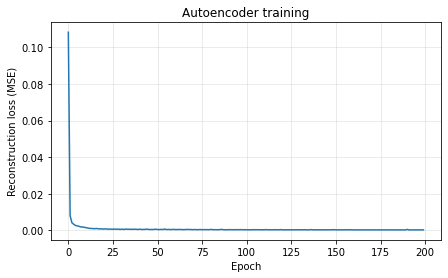

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction loss (MSE)")
plt.title("Autoencoder training")
plt.grid(True, alpha=0.3)
plt.show()

Extract encoder features:

In [12]:
model.eval()
with torch.no_grad():
    Z = model.encode(X_tensor.to(device)).cpu().numpy()

print("Encoder feature shape:", Z.shape)   # expect (6480, 32)
print("Feature mean:", Z.mean(), " std:", Z.std())

Encoder feature shape: (6480, 32)
Feature mean: 0.06427157  std: 0.5104929


Build the cutivar group array:

In [13]:
groups = []
for folder_name, meta in CULTIVARS.items():
    spectra = all_data.get(folder_name, [])
    for _ in spectra:
        groups.append(folder_name)

groups = np.array(groups)
print("groups shape:", groups.shape)          # expect (6480,)
print("unique cultivars:", len(np.unique(groups)))   # expect 20

groups shape: (6480,)
unique cultivars: 20


LOCO comparison, raw vs autoencoder features:

In [14]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.svm import LinearSVR

def loco_eval(features, y, groups, label):
    cultivars = np.unique(groups)
    y_true_all, y_pred_all = [], []

    for held in cultivars:
        train_mask = groups != held
        test_mask  = groups == held

        Xtr, Xte = features[train_mask], features[test_mask]
        ytr, yte = y[train_mask], y[test_mask]

        # scale features, fit on train cultivars only
        x_scaler = StandardScaler().fit(Xtr)
        Xtr_s = x_scaler.transform(Xtr)
        Xte_s = x_scaler.transform(Xte)

        # scale the target too, fit on train only, then invert predictions
        y_scaler = StandardScaler().fit(ytr.reshape(-1, 1))
        ytr_s = y_scaler.transform(ytr.reshape(-1, 1)).ravel()

        reg = LinearSVR(C=1.0, epsilon=0.01, max_iter=5000)
        reg.fit(Xtr_s, ytr_s)

        pred_s = reg.predict(Xte_s)
        pred = y_scaler.inverse_transform(pred_s.reshape(-1, 1)).ravel()

        y_true_all.extend(yte)
        y_pred_all.extend(pred)

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    rmse = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
    r2   = r2_score(y_true_all, y_pred_all)
    rpd  = y_true_all.std() / rmse

    print(f"{label:20s}  LOCO RMSE: {rmse:.4f}   R2: {r2:.4f}   RPD: {rpd:.3f}")
    return rmse, r2, rpd
X_raw_pre = snv(savitzky_golay_smooth(X))

print("LOCO results\n" + "-"*55)
loco_eval(X_raw_pre, y, groups, "Raw 1530 features")
loco_eval(Z,         y, groups, "AE 32 features")


LOCO results
-------------------------------------------------------


/usr/lib/python3/dist-packages/sklearn/svm/_base.py:976: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "
/usr/lib/python3/dist-packages/sklearn/svm/_base.py:976: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "
/usr/lib/python3/dist-packages/sklearn/svm/_base.py:976: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "
/usr/lib/python3/dist-packages/sklearn/svm/_base.py:976: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "
/usr/lib/python3/dist-packages/sklearn/svm/_base.py:976: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "


Raw 1530 features     LOCO RMSE: 0.0208   R2: -0.5975   RPD: 0.791


/usr/lib/python3/dist-packages/sklearn/svm/_base.py:976: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "
/usr/lib/python3/dist-packages/sklearn/svm/_base.py:976: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "
/usr/lib/python3/dist-packages/sklearn/svm/_base.py:976: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "
/usr/lib/python3/dist-packages/sklearn/svm/_base.py:976: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "
/usr/lib/python3/dist-packages/sklearn/svm/_base.py:976: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "


AE 32 features        LOCO RMSE: 0.0200   R2: -0.4742   RPD: 0.824


/usr/lib/python3/dist-packages/sklearn/svm/_base.py:976: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "


(0.019967509624696622, -0.4741791824828001, 0.8236161671028428)

In [15]:
from sklearn.svm import SVR

def loco_rbf(features, y, groups, label):
    cultivars = np.unique(groups)
    y_true_all, y_pred_all = [], []

    for held in cultivars:
        train_mask = groups != held
        test_mask  = groups == held

        Xtr, Xte = features[train_mask], features[test_mask]
        ytr, yte = y[train_mask], y[test_mask]

        x_scaler = StandardScaler().fit(Xtr)
        Xtr_s = x_scaler.transform(Xtr)
        Xte_s = x_scaler.transform(Xte)

        y_scaler = StandardScaler().fit(ytr.reshape(-1, 1))
        ytr_s = y_scaler.transform(ytr.reshape(-1, 1)).ravel()

        reg = SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.01, cache_size=1000)
        reg.fit(Xtr_s, ytr_s)

        pred_s = reg.predict(Xte_s)
        pred = y_scaler.inverse_transform(pred_s.reshape(-1, 1)).ravel()

        y_true_all.extend(yte)
        y_pred_all.extend(pred)

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    rmse = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
    r2   = r2_score(y_true_all, y_pred_all)
    rpd  = y_true_all.std() / rmse

    print(f"{label:22s}  LOCO RMSE: {rmse:.4f}   R2: {r2:.4f}   RPD: {rpd:.3f}")
    return rmse, r2, rpd

print("RBF on AE features\n" + "-"*55)
loco_rbf(Z, y, groups, "AE 32 features (RBF)")

RBF on AE features
-------------------------------------------------------
AE 32 features (RBF)    LOCO RMSE: 0.0186   R2: -0.2729   RPD: 0.886


(0.018554306908930927, -0.27289312618139605, 0.8863475108178711)

In [16]:
class SupervisedAE(nn.Module):
    def __init__(self, input_dim=1530, bottleneck=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(),
            nn.Linear(512, 128), nn.ReLU(),
            nn.Linear(128, bottleneck)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 128), nn.ReLU(),
            nn.Linear(128, 512), nn.ReLU(),
            nn.Linear(512, input_dim)
        )
        # prediction head off the bottleneck
        self.regressor = nn.Sequential(
            nn.Linear(bottleneck, 16), nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        pred = self.regressor(z).squeeze(-1)
        return recon, pred

In [17]:
import copy

def train_supervised_ae(features_pre, y, groups, alpha=1.0, epochs=150, verbose=False):
    """
    features_pre: SG+SNV preprocessed spectra, shape (6480, 1530)
    alpha: weight on prediction loss relative to reconstruction loss
    """
    cultivars = np.unique(groups)
    y_true_all, y_pred_all = [], []

    for held in cultivars:
        train_mask = groups != held
        test_mask  = groups == held

        Xtr = features_pre[train_mask]
        Xte = features_pre[test_mask]
        ytr = y[train_mask]
        yte = y[test_mask]

        # scale y on train only, invert at the end
        y_scaler = StandardScaler().fit(ytr.reshape(-1, 1))
        ytr_s = y_scaler.transform(ytr.reshape(-1, 1)).ravel()

        Xtr_t = torch.tensor(Xtr, dtype=torch.float32).to(device)
        Xte_t = torch.tensor(Xte, dtype=torch.float32).to(device)
        ytr_t = torch.tensor(ytr_s, dtype=torch.float32).to(device)

        model = SupervisedAE(input_dim=Xtr.shape[1], bottleneck=32).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=1e-3)
        mse = nn.MSELoss()

        model.train()
        for epoch in range(epochs):
            opt.zero_grad()
            recon, pred = model(Xtr_t)
            loss_recon = mse(recon, Xtr_t)
            loss_pred  = mse(pred, ytr_t)
            loss = loss_recon + alpha * loss_pred
            loss.backward()
            opt.step()

        # predict held out cultivar
        model.eval()
        with torch.no_grad():
            _, pred_s = model(Xte_t)
        pred_s = pred_s.cpu().numpy()
        pred = y_scaler.inverse_transform(pred_s.reshape(-1, 1)).ravel()

        y_true_all.extend(yte)
        y_pred_all.extend(pred)
        if verbose:
            print(f"  done {held}")

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    rmse = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
    r2   = r2_score(y_true_all, y_pred_all)
    rpd  = y_true_all.std() / rmse

    print(f"Supervised AE (alpha={alpha})  LOCO RMSE: {rmse:.4f}   R2: {r2:.4f}   RPD: {rpd:.3f}")
    return rmse, r2, rpd

In [18]:
# same SG+SNV data the plain AE used
X_pre = snv(savitzky_golay_smooth(X))

print("Supervised autoencoder, LOCO\n" + "-"*55)
train_supervised_ae(X_pre, y, groups, alpha=1.0, epochs=150)

Supervised autoencoder, LOCO
-------------------------------------------------------
Supervised AE (alpha=1.0)  LOCO RMSE: 0.0188   R2: -0.3097   RPD: 0.874


(0.018820421408780645, -0.30966781887685957, 0.8738148517763314)

Push alpha up:

In [19]:
print("Supervised AE, higher alpha\n" + "-"*55)
train_supervised_ae(X_pre, y, groups, alpha=50.0, epochs=150)

Supervised AE, higher alpha
-------------------------------------------------------
Supervised AE (alpha=50.0)  LOCO RMSE: 0.0188   R2: -0.3071   RPD: 0.875


(0.01880222576108, -0.3071366603938255, 0.8746604765124957)

Overall combos:

In [21]:
import json, time

results = []

def rbf_loco_on_features(Z, y, groups):
    cultivars = np.unique(groups)
    yt, yp = [], []
    for held in cultivars:
        tr, te = groups != held, groups == held
        xs = StandardScaler().fit(Z[tr])
        Xtr, Xte = xs.transform(Z[tr]), xs.transform(Z[te])
        ys = StandardScaler().fit(y[tr].reshape(-1,1))
        ytr = ys.transform(y[tr].reshape(-1,1)).ravel()
        reg = SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.01, cache_size=1000)
        reg.fit(Xtr, ytr)
        pred = ys.inverse_transform(reg.predict(Xte).reshape(-1,1)).ravel()
        yt.extend(y[te]); yp.extend(pred)
    yt, yp = np.array(yt), np.array(yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    return rmse, r2_score(yt, yp), yt.std()/rmse

def train_plain_ae(X_in, epochs=200):
    Xt = torch.tensor(X_in, dtype=torch.float32)
    loader = DataLoader(TensorDataset(Xt, Xt), batch_size=64, shuffle=True)
    m = Autoencoder(input_dim=X_in.shape[1], bottleneck=32).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3); crit = nn.MSELoss()
    for _ in range(epochs):
        m.train()
        for xb, _ in loader:
            xb = xb.to(device); opt.zero_grad()
            loss = crit(m(xb), xb); loss.backward(); opt.step()
    m.eval()
    with torch.no_grad():
        Z = m.encode(Xt.to(device)).cpu().numpy()
    return Z

print("Starting overnight sweep\n" + "="*60)
start = time.time()

for name, fn in preprocessing_combos.items():
    X_in = fn(X)
    print(f"\n[{name}]  {time.strftime('%H:%M:%S')}")

    # plain AE
    Z = train_plain_ae(X_in)
    rmse, r2, rpd = rbf_loco_on_features(Z, y, groups)
    results.append({"prep": name, "method": "plain_AE", "rmse": rmse, "r2": r2, "rpd": rpd})
    print(f"  plain AE       R2: {r2:.4f}")

    # supervised AE
    rmse, r2, rpd = train_supervised_ae(X_in, y, groups, alpha=1.0, epochs=150)
    results.append({"prep": name, "method": "supervised_AE", "rmse": rmse, "r2": r2, "rpd": rpd})

    # save after every combo so nothing is lost if the session drops
    with open("autoencoder_sweep_results.json", "w") as f:
        json.dump(results, f, indent=2)

print(f"\n{'='*60}\nDONE in {(time.time()-start)/60:.1f} min")
print("Results saved to autoencoder_sweep_results.json")

Starting overnight sweep

[SG + SNV]  15:07:48
  plain AE       R2: -0.3173
Supervised AE (alpha=1.0)  LOCO RMSE: 0.0193   R2: -0.3784   RPD: 0.852

[SG + MSC]  15:09:56
  plain AE       R2: -0.3757
Supervised AE (alpha=1.0)  LOCO RMSE: 0.0631   R2: -13.7139   RPD: 0.261

[SG + 1st Deriv]  15:11:51
  plain AE       R2: -0.1951
Supervised AE (alpha=1.0)  LOCO RMSE: 0.0192   R2: -0.3564   RPD: 0.859

[SG + 2nd Deriv]  15:14:07
  plain AE       R2: -0.1303
Supervised AE (alpha=1.0)  LOCO RMSE: 0.0204   R2: -0.5377   RPD: 0.806

[SG + SNV + 1st Der]  15:16:29
  plain AE       R2: -0.3548
Supervised AE (alpha=1.0)  LOCO RMSE: 0.0212   R2: -0.6563   RPD: 0.777

[SG + SNV + 2nd Der]  15:19:03
  plain AE       R2: -0.4109
Supervised AE (alpha=1.0)  LOCO RMSE: 0.0204   R2: -0.5455   RPD: 0.804

[SG + MSC + 1st Der]  15:21:17
  plain AE       R2: -0.3507
Supervised AE (alpha=1.0)  LOCO RMSE: 0.0185   R2: -0.2680   RPD: 0.888

[SG + MSC + 2nd Der]  15:24:50
  plain AE       R2: -0.3223
Supervised

In [22]:
import json
with open("autoencoder_sweep_results.json") as f:
    r = json.load(f)

print(f"{'Preprocessing':22s} {'Method':16s} {'R2':>8s} {'RMSE':>8s} {'RPD':>6s}")
print("-"*62)
for row in sorted(r, key=lambda x: -x['r2']):
    print(f"{row['prep']:22s} {row['method']:16s} {row['r2']:8.4f} {row['rmse']:8.4f} {row['rpd']:6.3f}")

Preprocessing          Method                 R2     RMSE    RPD
--------------------------------------------------------------
SG + 2nd Deriv         plain_AE          -0.1303   0.0175  0.941
SG + 1st Deriv         plain_AE          -0.1951   0.0180  0.915
SG + MSC + 1st Der     supervised_AE     -0.2680   0.0185  0.888
SG + SNV               plain_AE          -0.3173   0.0189  0.871
SG + MSC + 2nd Der     plain_AE          -0.3223   0.0189  0.870
SG + MSC + 1st Der     plain_AE          -0.3507   0.0191  0.860
SG + SNV + 1st Der     plain_AE          -0.3548   0.0191  0.859
SG + 1st Deriv         supervised_AE     -0.3564   0.0192  0.859
SG + MSC               plain_AE          -0.3757   0.0193  0.853
SG + SNV               supervised_AE     -0.3784   0.0193  0.852
SG + SNV + 2nd Der     plain_AE          -0.4109   0.0195  0.842
SG + MSC + 2nd Der     supervised_AE     -0.4389   0.0197  0.834
SG + 2nd Deriv         supervised_AE     -0.5377   0.0204  0.806
SG + SNV + 2nd Der     supe